# 01 — Dados: ECG (mitdb), ruídos (nstdb) e contaminação controlada

Objetivo: baixar os dados do PhysioNet, visualizar o ECG de referência e os ruídos reais, e demonstrar a função `contaminate` em SNRs conhecidos.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # raiz do repo no path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from src.data_io import ensure_datasets, load_ecg, load_noise, FS
from src.noise.contaminate import contaminate, powerline_60hz, SNR_TARGETS
from src.metrics.metrics import snr_db
ensure_datasets()  # baixa mitdb (100,103,105,115,215) + nstdb (bw,ma,em)

## ECG de referência (registro 100)

650000 amostras @ 360 Hz  (~30.1 min)


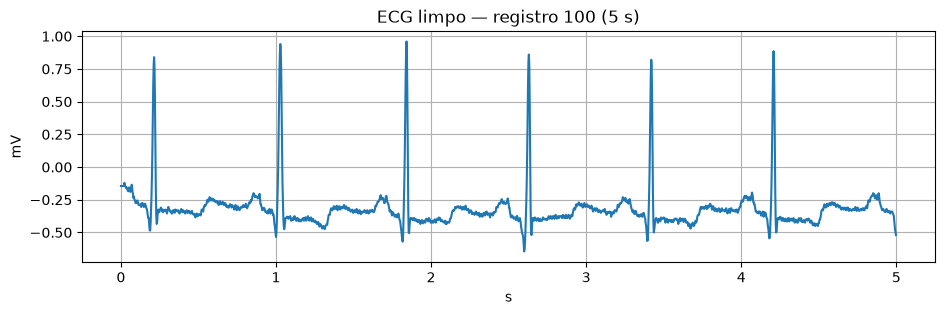

In [3]:
clean, fs = load_ecg('100')
print(f'{len(clean)} amostras @ {fs} Hz  (~{len(clean)/fs/60:.1f} min)')
t = np.arange(5*fs)/fs
plt.figure(figsize=(11,3)); plt.plot(t, clean[:5*fs]); plt.xlabel('s'); plt.ylabel('mV'); plt.title('ECG limpo — registro 100 (5 s)'); plt.grid(True)

## Ruídos reais do nstdb + senoide de 60 Hz

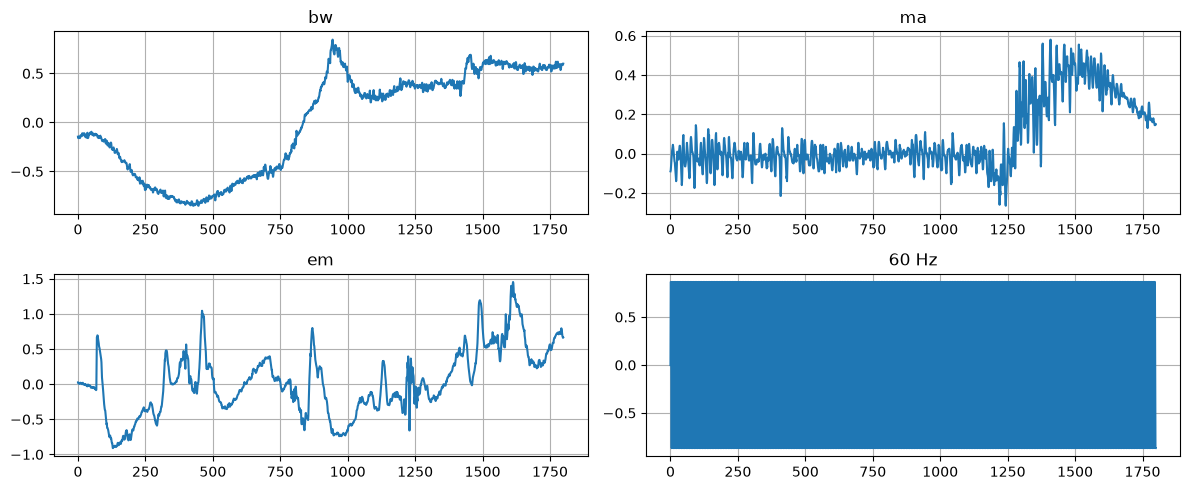

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(12,5))
for ax, nz in zip(axs.ravel(), ['bw','ma','em']):
    s = load_noise(nz); ax.plot(s[:5*FS]); ax.set_title(nz); ax.grid(True)
axs.ravel()[3].plot(powerline_60hz(5*FS)); axs.ravel()[3].set_title('60 Hz'); axs.ravel()[3].grid(True); fig.tight_layout()

## Contaminação em SNRs alvo (0/6/12/18 dB)

Verificamos que o SNR medido bate com o alvo (validação da escala).

In [5]:
for snr in SNR_TARGETS:
    noisy = contaminate(clean, '60hz', snr_db=snr)
    print(f'alvo {snr:2d} dB -> medido {snr_db(clean, noisy):.2f} dB')

alvo  0 dB -> medido -0.00 dB
alvo  6 dB -> medido 6.00 dB
alvo 12 dB -> medido 12.00 dB
alvo 18 dB -> medido 18.00 dB


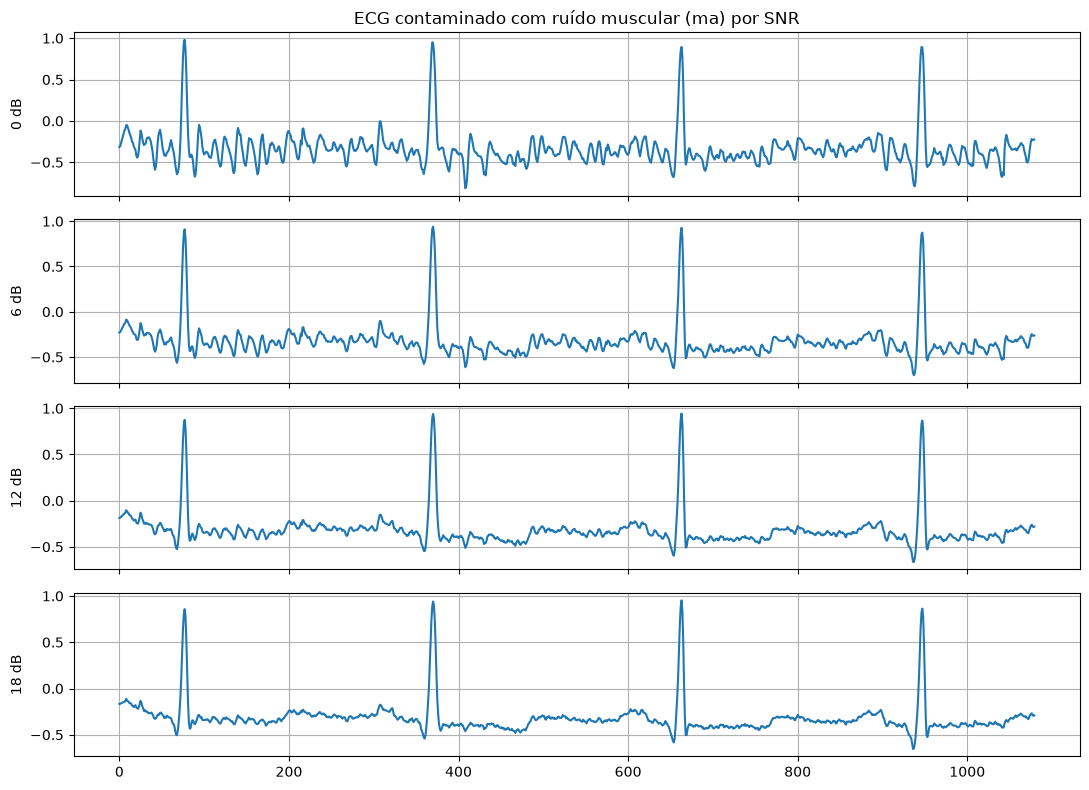

In [6]:
fig, axs = plt.subplots(len(SNR_TARGETS), 1, figsize=(11,8), sharex=True)
for ax, snr in zip(axs, SNR_TARGETS):
    noisy = contaminate(clean, 'ma', snr_db=snr)
    ax.plot(noisy[:3*FS]); ax.set_ylabel(f'{snr} dB'); ax.grid(True)
axs[0].set_title('ECG contaminado com ruído muscular (ma) por SNR'); fig.tight_layout()